--- Local Outlier Factor (LOF) ---
[*] Date încărcate pentru antrenare (Benigne 2017): 345659 rânduri.
[*] Date încărcate pentru testare (Total 2017): 100250 rânduri.
Antrenare LOF finalizată în 10.94s

1. RAPORT FINAL DE AUDIT (LOF):
SISTEM AUDIT SSH - REZULTATE LOCAL OUTLIER FACTOR (LOF)
Scor AUC: 0.9098
              precision    recall  f1-score   support

      Normal       0.97      0.85      0.90     86415
    Anomalie       0.47      0.85      0.60     13835

    accuracy                           0.85    100250
   macro avg       0.72      0.85      0.75    100250
weighted avg       0.90      0.85      0.86    100250


2. GENERARE MATRICE DE CONFUZIE...


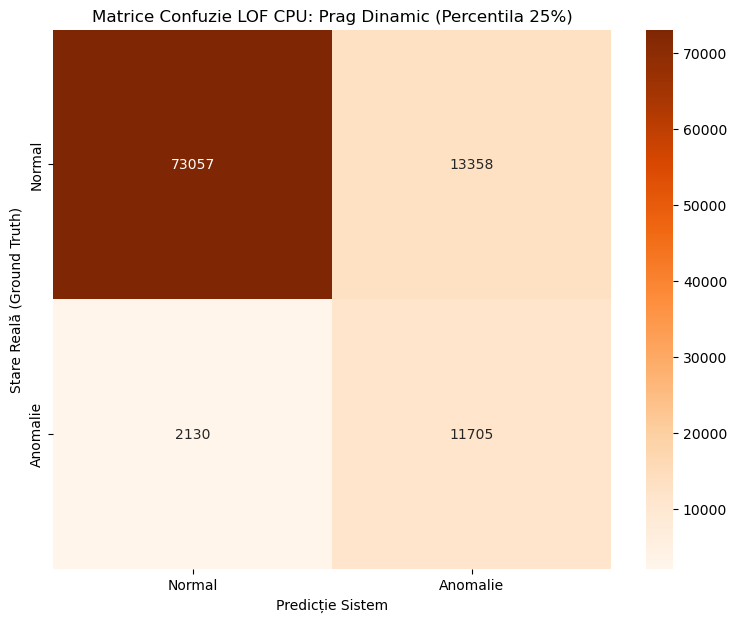


3. GENERARE CURBA ROC...


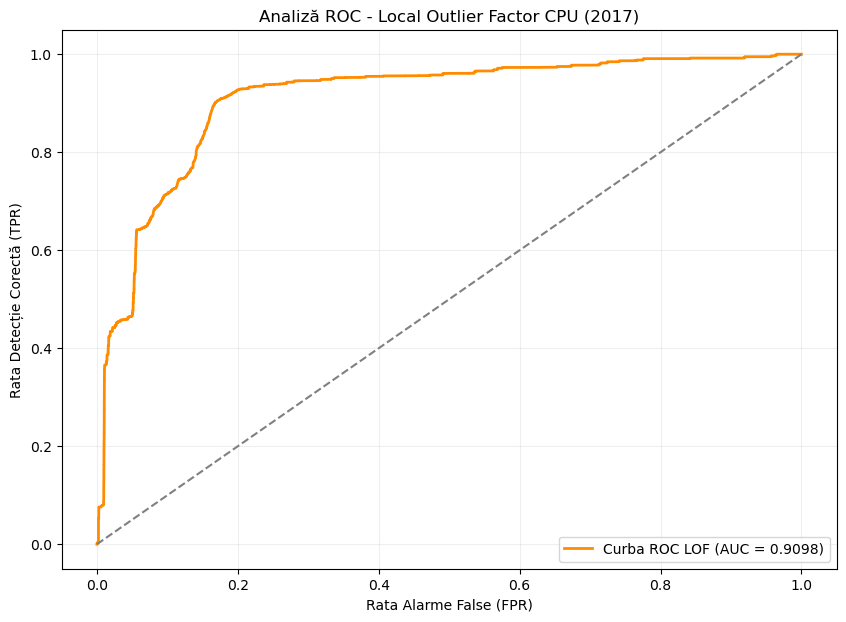


Rezultatele LOF au fost salvate cu succes în: D:\disertatie\rezultate_2017\LOF


In [1]:
import torch
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import time


prepro_path = r'D:\disertatie\preprocesare_anomalii_2017'
model_save_path = r'D:\disertatie\modele_2017\LOF'
rezultate_path = r'D:\disertatie\rezultate_2017\LOF'

for p in [model_save_path, rezultate_path]:
    os.makedirs(p, exist_ok=True)

print("--- Local Outlier Factor (LOF) ---")

#
X_train = torch.load(os.path.join(prepro_path, 'X_train_anomalii.pt')).numpy()
X_test = torch.load(os.path.join(prepro_path, 'X_test_anomalii.pt')).numpy()
y_test = torch.load(os.path.join(prepro_path, 'y_test_anomalii.pt')).numpy()
print(f"[*] Date încărcate pentru antrenare (Benigne 2017): {X_train.shape[0]} rânduri.")
print(f"[*] Date încărcate pentru testare (Total 2017): {X_test.shape[0]} rânduri.")

lof = LocalOutlierFactor(
    n_neighbors=35, 
    novelty=True, 
    contamination=0.15, 
    n_jobs=-1
)

start_time = time.time()
lof.fit(X_train)
print(f"Antrenare LOF finalizată în {time.time() - start_time:.2f}s")


decision_scores = lof.decision_function(X_test)
percentila_dorita = 25 
prag_dinamic = np.percentile(decision_scores, percentila_dorita)
y_pred = [1 if x < prag_dinamic else 0 for x in decision_scores]


y_scores = -decision_scores 
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

report = classification_report(y_test, y_pred, target_names=['Normal', 'Anomalie'])
full_report_text = f"SISTEM AUDIT SSH - REZULTATE LOCAL OUTLIER FACTOR (LOF)\n"
full_report_text += f"Scor AUC: {roc_auc:.4f}\n"
full_report_text += "="*50 + "\n"
full_report_text += report

print("\n1. RAPORT FINAL DE AUDIT (LOF):")
print(full_report_text)

with open(os.path.join(rezultate_path, 'raport_final_lof_cpu.txt'), 'w') as f:
    f.write(full_report_text)

print("\n2. GENERARE MATRICE DE CONFUZIE...")
plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Normal', 'Anomalie'], yticklabels=['Normal', 'Anomalie'])
plt.title(f'Matrice Confuzie LOF CPU: Prag Dinamic (Percentila {percentila_dorita}%)')
plt.ylabel('Stare Reală (Ground Truth)')
plt.xlabel('Predicție Sistem')
plt.savefig(os.path.join(rezultate_path, 'matrice_confuzie_lof_cpu.png'), dpi=300)
plt.show()

print("\n3. GENERARE CURBA ROC...")
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curba ROC LOF (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Rata Alarme False (FPR)')
plt.ylabel('Rata Detecție Corectă (TPR)')
plt.title('Analiză ROC - Local Outlier Factor CPU (2017)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.savefig(os.path.join(rezultate_path, 'curba_roc_lof_cpu.png'), dpi=300)
plt.show()

joblib.dump(lof, os.path.join(model_save_path, 'model_lof_final_cpu.pkl'))
print(f"\nRezultatele LOF au fost salvate cu succes în: {rezultate_path}")